# 03 — Classical ML Experiments — Home Credit Default Risk

**Scope**: complete Classical ML track (Logistic Regression, Decision Tree, Random Forest,
Gradient Boosting/XGBoost), ending with one saved, calibrated, threshold-tuned best model.
No Deep Learning, SHAP, Streamlit, or deployment happens here.

**Inputs** (from `01_eda.ipynb`, not recomputed here): `X_train`, `X_test`, `y_train`, `y_test`,
the fitted preprocessing pipeline, the final feature list, and the validation strategy.

## The one rule that shapes every design choice below
**The Test set is touched exactly once, at the very end, for a single final evaluation.**
Every model-selection, tuning, threshold, and calibration decision before that point is made using
either 5-fold Stratified CV metrics or **out-of-fold (OOF) predictions** on the training set —
never a fresh split of Train and never Test.

- *Why OOF predictions instead of carving out a fresh validation split from Train?* Splitting Train
  again would throw away CV's main advantage (using 100% of Train for both fitting and honest
  evaluation) and reduce the data available for the already-imbalanced minority class. OOF
  predictions give every Train row an evaluation-quality prediction — made by a fold that never saw
  that row during fitting — without sacrificing any data or touching Test.
- *Why does SMOTE specifically need `imbalanced-learn`'s `Pipeline` rather than scikit-learn's?*
  scikit-learn's `Pipeline` has no concept of a resampling step - if SMOTE were applied before
  `cross_val_score`/`cross_validate`, it would run on the *whole* training fold set at once,
  synthesizing minority examples that could leak information into the validation fold of that same
  CV split. `imblearn.pipeline.Pipeline` makes `fit_resample` a first-class pipeline step that
  cross-validation tooling correctly re-runs fresh inside every single fold's training portion only.


## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from datetime import datetime, timezone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    recall_score, precision_score, f1_score, confusion_matrix,
    brier_score_loss, RocCurveDisplay,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = r"C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models", "versioned_artifacts")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


## 1. Load saved EDA/feature-preparation artifacts

Nothing here is recomputed - everything comes straight from `01_eda.ipynb`'s saved outputs.

In [2]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze()

preprocessor = joblib.load(os.path.join(MODELS_DIR, "preprocessing_pipeline.joblib"))

with open(os.path.join(REPORTS_DIR, "final_ml_feature_list.json")) as f:
    feature_lists = json.load(f)

with open(os.path.join(REPORTS_DIR, "validation_strategy.json")) as f:
    validation_strategy = json.load(f)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "(shape only - contents untouched until Section 8)")
print("Train default rate:", y_train.mean().round(4))
print("Numeric features:", len(feature_lists["numeric_features"]),
      "| Categorical features:", len(feature_lists["categorical_features"]))
print("Saved validation strategy:", validation_strategy["cv_strategy"],
      f"({validation_strategy['n_splits']}-fold, random_state={validation_strategy['random_state']})")

assert list(X_train.columns) == list(X_test.columns), "X_train/X_test column mismatch!"
print("\n[OK] X_train and X_test share the exact same feature columns (structural check only -")
print("     no values from X_test are read or transformed here; X_test stays untouched until Section 8).")

# Explicit lock, mirroring the same discipline used in 01_eda.ipynb: a visible marker that
# X_test/y_test values must not be read again anywhere before Section 8.
TEST_SET_LOCKED_UNTIL_SECTION = 8

cv = StratifiedKFold(
    n_splits=validation_strategy["n_splits"], shuffle=True, random_state=validation_strategy["random_state"]
)
scale_pos_weight = validation_strategy["scale_pos_weight"]


X_train: (246008, 586) | X_test: (61503, 586) (shape only - contents untouched until Section 8)
Train default rate: 0.0807
Numeric features: 570 | Categorical features: 16
Saved validation strategy: StratifiedKFold (5-fold, random_state=42)

[OK] X_train and X_test share the exact same feature columns (structural check only -
     no values from X_test are read or transformed here; X_test stays untouched until Section 8).


## 2. Candidate models and imbalance strategies

`get_model()` builds a **fresh estimator** for every (model x imbalance strategy) combination:
`class_weight="balanced"` (or `scale_pos_weight` for XGBoost) is only applied when the strategy
is `"class_weight"`; for the `"smote"` strategy the estimator gets no class weighting, since SMOTE
is the one handling the imbalance. `make_pipeline()` then wraps that estimator with the
preprocessing (and, when requested, a SMOTE step) inside an `imblearn.pipeline.Pipeline`, so the
same object can be evaluated either **with** or **without** SMOTE - SMOTE only ever runs on a
fold's own training portion, never its validation portion, because `cross_val_predict`/`cross_validate`
re-fits the whole pipeline (imputer, scaler, encoder, SMOTE, model) from scratch inside every fold.

In [3]:
# Model and Imbalance Strategy Setup

def make_pipeline(model, use_smote: bool):
    """
    Build a leakage-safe pipeline:
    preprocessing -> optional SMOTE -> model

    SMOTE is applied only to the training portion of each
    cross-validation fold through imbalanced-learn Pipeline.
    """
    steps = [
        ("preprocessing", clone(preprocessor))
    ]

    if use_smote:
        steps.append(
            ("smote", SMOTE(random_state=RANDOM_STATE))
        )

    steps.append(
        ("model", model)
    )

    return ImbPipeline(steps=steps)


def get_model(model_name: str, strategy: str):
    """
    Create each model with the selected imbalance strategy.

    For class_weight:
      - Logistic Regression / Decision Tree / Random Forest
        use class_weight='balanced'
      - XGBoost uses the equivalent scale_pos_weight

    For SMOTE:
      - No class weighting is applied
      - SMOTE handles class imbalance inside each CV fold
    """

    if model_name == "LogisticRegression":
        return LogisticRegression(
            max_iter=1000,
            class_weight="balanced" if strategy == "class_weight" else None,
            random_state=RANDOM_STATE
        )

    elif model_name == "DecisionTree":
        return DecisionTreeClassifier(
            max_depth=8,
            class_weight="balanced" if strategy == "class_weight" else None,
            random_state=RANDOM_STATE
        )

    elif model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced" if strategy == "class_weight" else None,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=300,
            scale_pos_weight=scale_pos_weight if strategy == "class_weight" else 1.0,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")


# Required classical ML models
model_names = [
    "LogisticRegression",
    "DecisionTree",
    "RandomForest",
    "XGBoost",
]

# Imbalance strategies to compare
imbalance_strategies = [
    "class_weight",
    "smote",
]

print("Models:")
for model_name in model_names:
    print(" -", model_name)

print("\nImbalance strategies:")
for strategy in imbalance_strategies:
    print(" -", strategy)

print("\nExpected baseline configurations:")
for model_name in model_names:
    for strategy in imbalance_strategies:
        print(f" - {model_name} + {strategy}")

print("\n[OK] Model and imbalance strategy setup complete.")

Models:
 - LogisticRegression
 - DecisionTree
 - RandomForest
 - XGBoost

Imbalance strategies:
 - class_weight
 - smote

Expected baseline configurations:
 - LogisticRegression + class_weight
 - LogisticRegression + smote
 - DecisionTree + class_weight
 - DecisionTree + smote
 - RandomForest + class_weight
 - RandomForest + smote
 - XGBoost + class_weight
 - XGBoost + smote

[OK] Model and imbalance strategy setup complete.


## 3. Model comparison via 5-fold Stratified CV (out-of-fold predictions)

For every (model × imbalance strategy) combination, `cross_val_predict` with `method="predict_proba"`
produces one out-of-fold probability per training row - each row's prediction comes from the one
fold that did **not** train on it, so this is an honest, leakage-free estimate of held-out
performance using 100% of Train, and it doubles as the exact input we'll need later for
threshold optimization and calibration (Sections 6-7) without ever touching Test.

In [6]:
# Initialize experiment results

comparison_rows = []
oof_predictions = {}

print("[OK] Experiment containers initialized.")


# Logistic Regression + class_weight


model_name = "LogisticRegression"
strategy = "class_weight"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=False)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_predictions[f"{model_name}__{strategy}"] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {model_name} + {strategy}")

[OK] Experiment containers initialized.
[done] LogisticRegression + class_weight


In [7]:
# Decision Tree + class_weight

model_name = "DecisionTree"
strategy = "class_weight"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=False)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_predictions[f"{model_name}__{strategy}"] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {model_name} + {strategy}")

[done] DecisionTree + class_weight


In [8]:
# Random Forest + class_weight

model_name = "RandomForest"
strategy = "class_weight"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=False)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_predictions[f"{model_name}__{strategy}"] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {model_name} + {strategy}")

[done] RandomForest + class_weight


In [9]:
# XGBoost + scale_pos_weight

model_name = "XGBoost"
strategy = "class_weight"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=False)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_predictions[f"{model_name}__{strategy}"] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {model_name} + {strategy}")

[done] XGBoost + class_weight


In [10]:
# Baseline comparison

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

print(comparison_df.round(4).to_string(index=False))

comparison_df.to_csv(
    os.path.join(REPORTS_DIR, "model_comparison_cv_results.csv"),
    index=False
)

             model imbalance_strategy  roc_auc  pr_auc  recall@0.5  precision@0.5  f1@0.5
LogisticRegression       class_weight   0.7693  0.2463      0.6977         0.1740  0.2785
           XGBoost       class_weight   0.7345  0.2221      0.4254         0.2199  0.2899
      RandomForest       class_weight   0.7403  0.2071      0.0017         0.5397  0.0034
      DecisionTree       class_weight   0.7047  0.1832      0.6637         0.1428  0.2350


In [11]:
# Logistic Regression + SMOTE

model_name = "LogisticRegression"
strategy = "smote"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=True)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

combo_name = f"{model_name}__{strategy}"
oof_predictions[combo_name] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {combo_name}")

[done] LogisticRegression__smote


In [12]:
# Decision Tree + SMOTE

model_name = "DecisionTree"
strategy = "smote"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=True)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

combo_name = f"{model_name}__{strategy}"
oof_predictions[combo_name] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {combo_name}")

[done] DecisionTree__smote


In [13]:
# Random Forest + SMOTE

model_name = "RandomForest"
strategy = "smote"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=True)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

combo_name = f"{model_name}__{strategy}"
oof_predictions[combo_name] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {combo_name}")

[done] RandomForest__smote


In [14]:
# XGBoost + SMOTE

model_name = "XGBoost"
strategy = "smote"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=True)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

combo_name = f"{model_name}__{strategy}"
oof_predictions[combo_name] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {combo_name}")

[done] XGBoost__smote


In [15]:
# Final comparison: all 8 configurations

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

print(comparison_df.round(4).to_string(index=False))

comparison_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "model_comparison_cv_results.csv"
    ),
    index=False
)

print("\n[OK] All 8 baseline configurations compared.")

             model imbalance_strategy  roc_auc  pr_auc  recall@0.5  precision@0.5  f1@0.5
LogisticRegression       class_weight   0.7693  0.2463      0.6977         0.1740  0.2785
LogisticRegression              smote   0.7591  0.2400      0.6709         0.1727  0.2747
           XGBoost              smote   0.7499  0.2307      0.0721         0.4030  0.1223
           XGBoost       class_weight   0.7345  0.2221      0.4254         0.2199  0.2899
      RandomForest       class_weight   0.7403  0.2071      0.0017         0.5397  0.0034
      RandomForest              smote   0.7225  0.2000      0.0021         0.6562  0.0042
      DecisionTree       class_weight   0.7047  0.1832      0.6637         0.1428  0.2350
      DecisionTree              smote   0.6581  0.1297      0.0810         0.1624  0.1081

[OK] All 8 baseline configurations compared.


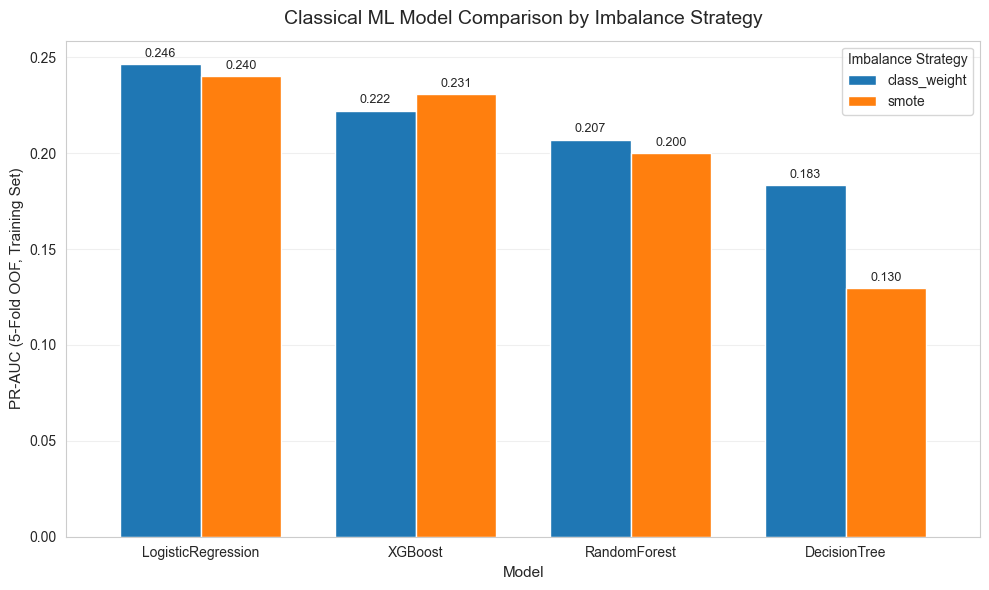

In [17]:
# Model x Imbalance Strategy — PR-AUC Comparison

fig, ax = plt.subplots(figsize=(10, 6))

# Pivot results
plot_df = comparison_df.pivot(
    index="model",
    columns="imbalance_strategy",
    values="pr_auc"
)

# Sort models by their best PR-AUC
plot_df = plot_df.loc[
    plot_df.max(axis=1).sort_values(ascending=False).index
]

# Plot
plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.75
)

# Add PR-AUC values on top of each bar
for container in ax.containers:
    labels = [
        f"{bar.get_height():.3f}" if np.isfinite(bar.get_height()) else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

# Titles and labels
ax.set_title(
    "Classical ML Model Comparison by Imbalance Strategy",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("PR-AUC (5-Fold OOF, Training Set)", fontsize=11)

# Improve x-axis labels
ax.tick_params(axis="x", rotation=0)

# Legend
ax.legend(
    title="Imbalance Strategy",
    loc="upper right",
    frameon=True
)

# Grid only on y-axis
ax.grid(axis="y", alpha=0.3)
ax.grid(axis="x", visible=False)

plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "model_comparison_pr_auc.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


## 4. Select the Top Two Candidates for Hyperparameter Tuning

**PR-AUC is the primary baseline selection metric** rather than accuracy because the positive class
(default) is rare and business-critical, with approximately 8% prevalence. PR-AUC is especially
informative for evaluating minority-class ranking under strong class imbalance.

ROC-AUC, recall, precision, and F1 are also reported for a complete comparison.

Based on the baseline results, the strongest configurations from the two leading model families
(Logistic Regression and XGBoost) are selected for **hyperparameter tuning**.

The final champion model will be chosen only after tuning, followed by threshold optimization,
probability calibration, and final evaluation on the locked Test set.


In [19]:
# Select top two model candidates for hyperparameter tuning

# Top candidate by PR-AUC
logistic_candidate = comparison_df[
    comparison_df["model"] == "LogisticRegression"
].sort_values("pr_auc", ascending=False).iloc[0]

# Top XGBoost candidate by PR-AUC
xgb_candidate = comparison_df[
    comparison_df["model"] == "XGBoost"
].sort_values("pr_auc", ascending=False).iloc[0]

tuning_candidates = pd.DataFrame([
    logistic_candidate,
    xgb_candidate
]).reset_index(drop=True)

print("Selected candidates for hyperparameter tuning:\n")
print(
    tuning_candidates[
        [
            "model",
            "imbalance_strategy",
            "pr_auc",
            "roc_auc",
            "recall@0.5",
            "precision@0.5",
            "f1@0.5"
        ]
    ].round(4).to_string(index=False)
)

Selected candidates for hyperparameter tuning:

             model imbalance_strategy  pr_auc  roc_auc  recall@0.5  precision@0.5  f1@0.5
LogisticRegression       class_weight  0.2463   0.7693      0.6977          0.174  0.2785
           XGBoost              smote  0.2307   0.7499      0.0721          0.403  0.1223


## 5. Hyperparameter tuning — selected candidate only

`RandomizedSearchCV` reuses the same `StratifiedKFold` object and is scored on PR-AUC, so the
search itself never touches Test. Only the winning (model, imbalance strategy) pair from Section 4
is tuned - the other three models are not retuned, per the brief.

In [22]:
# Hyperparameter Search Spaces — Top 2 Candidates

PARAM_DISTRIBUTIONS = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    },

    "XGBoost": {
        "model__n_estimators": [100,200],
        "model__max_depth": [3, 4, 6],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.85, 1.0],
    },
}

print("[OK] Compact tuning search spaces prepared.")

[OK] Compact tuning search spaces prepared.


In [21]:
# Hyperparameter Tuning — Logistic Regression

from sklearn.model_selection import GridSearchCV

logistic_strategy = (
    tuning_candidates.loc[
        tuning_candidates["model"] == "LogisticRegression",
        "imbalance_strategy"
    ].iloc[0]
)

logistic_pipe = make_pipeline(
    get_model("LogisticRegression", logistic_strategy),
    use_smote=(logistic_strategy == "smote")
)

logistic_search = GridSearchCV(
    estimator=logistic_pipe,
    param_grid=PARAM_DISTRIBUTIONS["LogisticRegression"],
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=False,
)

logistic_search.fit(X_train, y_train)

print("Logistic Regression tuning completed.")
print("Best CV PR-AUC:", round(logistic_search.best_score_, 4))
print("Best parameters:")

for k, v in logistic_search.best_params_.items():
    print(f"  {k}: {v}")

tuned_logistic_pipeline = logistic_search.best_estimator_

c:\Users\Kirolos George\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Kirolos George\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown

Logistic Regression tuning completed.
Best CV PR-AUC: 0.2475
Best parameters:
  model__C: 0.01


In [23]:
# Hyperparameter Tuning — XGBoost

xgb_strategy = (
    tuning_candidates.loc[
        tuning_candidates["model"] == "XGBoost",
        "imbalance_strategy"
    ].iloc[0]
)

xgb_pipe = make_pipeline(
    get_model("XGBoost", xgb_strategy),
    use_smote=(xgb_strategy == "smote")
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=PARAM_DISTRIBUTIONS["XGBoost"],
    n_iter=4,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    return_train_score=False,
)

xgb_search.fit(X_train, y_train)

print("XGBoost tuning completed.")
print("Best CV PR-AUC:", round(xgb_search.best_score_, 4))
print("Best parameters:")

for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")

tuned_xgb_pipeline = xgb_search.best_estimator_

XGBoost tuning completed.
Best CV PR-AUC: 0.2514
Best parameters:
  model__subsample: 0.85
  model__n_estimators: 200
  model__max_depth: 4
  model__learning_rate: 0.1


In [24]:
# Compare Tuned Logistic Regression vs Tuned XGBoost

tuned_results = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "imbalance_strategy": logistic_strategy,
        "cv_pr_auc_tuned": logistic_search.best_score_,
    },
    {
        "model": "XGBoost",
        "imbalance_strategy": xgb_strategy,
        "cv_pr_auc_tuned": xgb_search.best_score_,
    },
]).sort_values(
    "cv_pr_auc_tuned",
    ascending=False
).reset_index(drop=True)

print(tuned_results.round(4).to_string(index=False))

tuned_results.to_csv(
    os.path.join(REPORTS_DIR, "tuned_model_comparison.csv"),
    index=False
)

             model imbalance_strategy  cv_pr_auc_tuned
           XGBoost              smote           0.2514
LogisticRegression       class_weight           0.2475


## 6. Threshold Optimization via a Business Cost Matrix (OOF Predictions, No Test)

The two tuned candidates — **Logistic Regression + class_weight** and **XGBoost + SMOTE** — are evaluated using
the same business-cost framework before selecting the final classical champion.

Because missing a true default is expected to be more costly than rejecting a good applicant, we use
illustrative business costs:

* **False Negative (FN) cost = 10**
* **False Positive (FP) cost = 1**

These values are assumptions for demonstration. The **cost ratio**, rather than the absolute values,
drives the threshold decision and should be replaced by the institution's real unit economics later.

For each tuned candidate, we generate **out-of-fold (OOF) probability predictions on the Training set**
and scan multiple classification thresholds. For every threshold, we calculate false positives, false
negatives, precision, recall, F1, and total business cost.

The selected threshold for each candidate is the one that minimizes the illustrative business cost.
The **Test set is not used** for threshold selection.

After threshold optimization, the two candidates are compared using both their business-cost results and
the previously reported predictive metrics. The final classical champion is selected only after this
comparison, before any final Test evaluation.


Threshold optimization: LogisticRegression
FN_COST = 10
FP_COST = 1
Optimal threshold: 0.520
Minimum OOF business cost: 125559
Cost at threshold 0.50: 125997
Threshold optimization: XGBoost
FN_COST = 10
FP_COST = 1
Optimal threshold: 0.110
Minimum OOF business cost: 127086
Cost at threshold 0.50: 194491


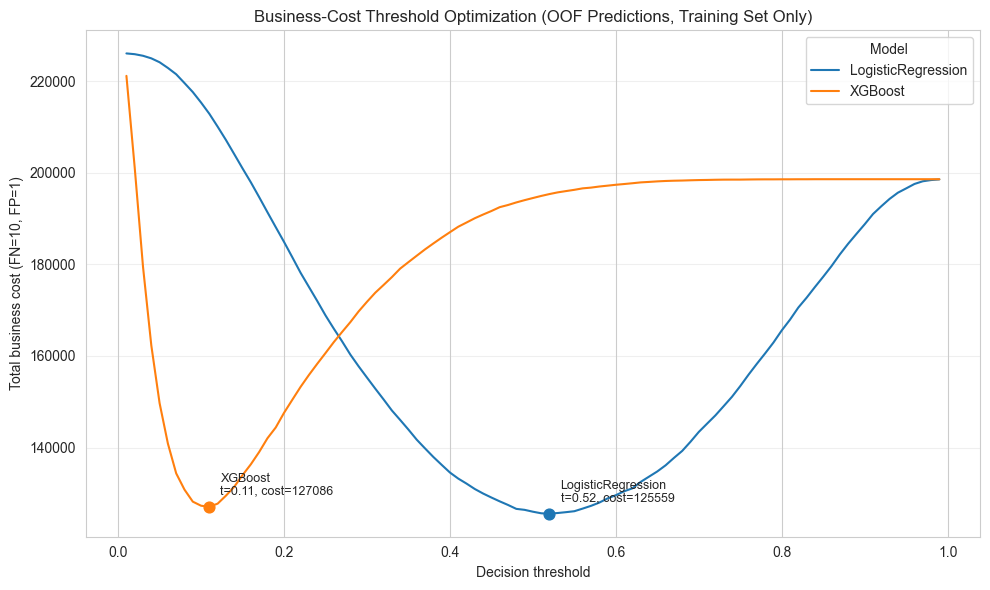


Optimal threshold summary:
             model  optimal_threshold  minimum_business_cost
LogisticRegression               0.52                 125559
           XGBoost               0.11                 127086


In [25]:
# Section 6 — Business-Cost Threshold Optimization

FN_COST = 10  # cost of missing an actual default
FP_COST = 1   # cost of wrongly rejecting a good applicant

thresholds = np.linspace(0.01, 0.99, 99)

# Tuned candidates
tuned_candidates = {
    "LogisticRegression": tuned_logistic_pipeline,
    "XGBoost": tuned_xgb_pipeline,
}

threshold_results = []
optimal_thresholds = {}
tuned_oof_predictions = {}


for model_name, tuned_pipeline in tuned_candidates.items():

    print(f"Threshold optimization: {model_name}")

    # Generate OOF probabilities from the tuned pipeline
    # using Training data only.
    tuned_oof_proba = cross_val_predict(
        tuned_pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    tuned_oof_predictions[model_name] = tuned_oof_proba

    costs = []

    for threshold in thresholds:
        pred = (tuned_oof_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            pred
        ).ravel()

        total_cost = (
            fn * FN_COST +
            fp * FP_COST
        )

        costs.append(total_cost)

        threshold_results.append({
            "model": model_name,
            "threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "recall": recall_score(y_train, pred),
            "precision": precision_score(
                y_train,
                pred,
                zero_division=0
            ),
            "f1": f1_score(y_train, pred),
            "total_cost": total_cost,
        })

    costs = np.array(costs)

    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]

    optimal_thresholds[model_name] = best_threshold

    default_05_idx = np.argmin(np.abs(thresholds - 0.50))

    print(f"FN_COST = {FN_COST}")
    print(f"FP_COST = {FP_COST}")
    print(f"Optimal threshold: {best_threshold:.3f}")
    print(f"Minimum OOF business cost: {costs[best_idx]:.0f}")
    print(
        f"Cost at threshold 0.50: "
        f"{costs[default_05_idx]:.0f}"
    )



# Save threshold analysis

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "threshold_analysis.csv"
    ),
    index=False
)



# Save selected thresholds

threshold_config = {
    "FN_COST": FN_COST,
    "FP_COST": FP_COST,
    "thresholds_evaluated": [float(t) for t in thresholds],
    "optimal_thresholds": {
        model: float(threshold)
        for model, threshold in optimal_thresholds.items()
    },
}

with open(
    os.path.join(
        REPORTS_DIR,
        "optimal_thresholds.json"
    ),
    "w"
) as f:
    json.dump(
        threshold_config,
        f,
        indent=2
    )



# Plot business-cost curves

fig, ax = plt.subplots(figsize=(10, 6))

for model_name in tuned_candidates.keys():

    model_curve = threshold_results_df[
        threshold_results_df["model"] == model_name
    ]

    ax.plot(
        model_curve["threshold"],
        model_curve["total_cost"],
        label=model_name
    )

    best_t = optimal_thresholds[model_name]
    best_cost = model_curve.loc[
        model_curve["threshold"] == best_t,
        "total_cost"
    ].iloc[0]

    ax.scatter(
        best_t,
        best_cost,
        s=60,
        zorder=3
    )

    ax.annotate(
        f"{model_name}\n"
        f"t={best_t:.2f}, cost={best_cost:.0f}",
        (best_t, best_cost),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("Decision threshold")
ax.set_ylabel(
    f"Total business cost "
    f"(FN={FN_COST}, FP={FP_COST})"
)

ax.set_title(
    "Business-Cost Threshold Optimization "
    "(OOF Predictions, Training Set Only)"
)

ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "threshold_cost_curves.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()



# Final threshold comparison

threshold_summary = pd.DataFrame([
    {
        "model": model_name,
        "optimal_threshold": optimal_thresholds[model_name],
        "minimum_business_cost": threshold_results_df[
            threshold_results_df["model"] == model_name
        ]["total_cost"].min(),
    }
    for model_name in tuned_candidates.keys()
])

print("\nOptimal threshold summary:")
print(
    threshold_summary
    .round(4)
    .to_string(index=False)
)

## 7. Probability Calibration — Tuned Logistic Regression and XGBoost

The two tuned candidates — **Logistic Regression + class_weight** and **XGBoost + SMOTE** — are evaluated for
probability calibration using their existing **out-of-fold (OOF) predictions on the Training set**.

Two calibration methods are compared:

* **Sigmoid (Platt scaling)**
* **Isotonic regression**

Because the OOF predictions were generated from models that did not see their corresponding validation
rows during fitting, they provide an evaluation-safe basis for comparing calibration quality without
using the Test set.

For each candidate, the calibrated probabilities are compared using **Brier score**. The calibration
method with the lower OOF Brier score is selected for that candidate.

After calibration, the corresponding calibrated OOF probabilities will also be used to re-check the
business decision threshold. The final calibrated candidates will then be evaluated on the locked Test
set only after all model, calibration, and threshold decisions are fixed.


In [27]:
# Section 7 — Probability Calibration
# Tuned Logistic Regression + Tuned XGBoost

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

calibration_results = []
calibrators = {}
calibrated_oof_predictions = {}

tuned_candidates = {
    "LogisticRegression": tuned_logistic_pipeline,
    "XGBoost": tuned_xgb_pipeline,
}

# Use the OOF predictions already generated in Section 6.
# They correspond to the tuned candidates and contain no Test information.
for model_name in tuned_candidates:

    print(f"Calibration: {model_name}")

    raw_oof_proba = tuned_oof_predictions[model_name]


    # 1. Uncalibrated Brier score
   

    uncalibrated_brier = brier_score_loss(
        y_train,
        raw_oof_proba
    )

    print(
        f"Uncalibrated OOF Brier: "
        f"{uncalibrated_brier:.5f}"
    )

   
    # 2. Sigmoid / Platt scaling
  

    # Fit logistic regression on OOF probabilities only.
    # Categorical/feature preprocessing is not needed here
    # because the input is a single probability.
    sigmoid_calibrator = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    sigmoid_calibrator.fit(
        raw_oof_proba.reshape(-1, 1),
        y_train
    )

    sigmoid_oof_proba = sigmoid_calibrator.predict_proba(
        raw_oof_proba.reshape(-1, 1)
    )[:, 1]

    sigmoid_brier = brier_score_loss(
        y_train,
        sigmoid_oof_proba
    )


    # 3. Isotonic regression
  
    isotonic_calibrator = IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip"
    )

    isotonic_calibrator.fit(
        raw_oof_proba,
        y_train
    )

    isotonic_oof_proba = isotonic_calibrator.predict(
        raw_oof_proba
    )

    isotonic_brier = brier_score_loss(
        y_train,
        isotonic_oof_proba
    )


    # 4. Store results


    calibration_results.extend([
        {
            "model": model_name,
            "method": "none",
            "brier_score": uncalibrated_brier
        },
        {
            "model": model_name,
            "method": "sigmoid",
            "brier_score": sigmoid_brier
        },
        {
            "model": model_name,
            "method": "isotonic",
            "brier_score": isotonic_brier
        },
    ])

    # Store calibrated OOF probabilities
    calibrated_oof_predictions[
        f"{model_name}__sigmoid"
    ] = sigmoid_oof_proba

    calibrated_oof_predictions[
        f"{model_name}__isotonic"
    ] = isotonic_oof_proba

    # Select the better calibration method
    method_scores = {
        "sigmoid": sigmoid_brier,
        "isotonic": isotonic_brier
    }

    best_method = min(
        method_scores,
        key=method_scores.get
    )

    calibrators[model_name] = {
        "sigmoid": sigmoid_calibrator,
        "isotonic": isotonic_calibrator,
        "selected_method": best_method
    }

    print(f"Sigmoid OOF Brier:  {sigmoid_brier:.5f}")
    print(f"Isotonic OOF Brier: {isotonic_brier:.5f}")
    print(f"Selected method:    {best_method}")



# Calibration comparison table


calibration_df = (
    pd.DataFrame(calibration_results)
    .sort_values(
        ["model", "brier_score"]
    )
    .reset_index(drop=True)
)

print("\nCalibration comparison:")
print(
    calibration_df
    .round(5)
    .to_string(index=False)
)

calibration_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "calibration_comparison.csv"
    ),
    index=False
)



# Save selected calibration methods


selected_calibration = {
    model_name: info["selected_method"]
    for model_name, info in calibrators.items()
}

with open(
    os.path.join(
        REPORTS_DIR,
        "selected_calibration_methods.json"
    ),
    "w"
) as f:
    json.dump(
        selected_calibration,
        f,
        indent=2
    )

print("\nSelected calibration methods:")
for model_name, method in selected_calibration.items():
    print(f" - {model_name}: {method}")

Calibration: LogisticRegression
Uncalibrated OOF Brier: 0.19358
Sigmoid OOF Brier:  0.06744
Isotonic OOF Brier: 0.06733
Selected method:    isotonic
Calibration: XGBoost
Uncalibrated OOF Brier: 0.06746
Sigmoid OOF Brier:  0.06816
Isotonic OOF Brier: 0.06729
Selected method:    isotonic

Calibration comparison:
             model   method  brier_score
LogisticRegression isotonic      0.06733
LogisticRegression  sigmoid      0.06744
LogisticRegression     none      0.19358
           XGBoost isotonic      0.06729
           XGBoost     none      0.06746
           XGBoost  sigmoid      0.06816

Selected calibration methods:
 - LogisticRegression: isotonic
 - XGBoost: isotonic


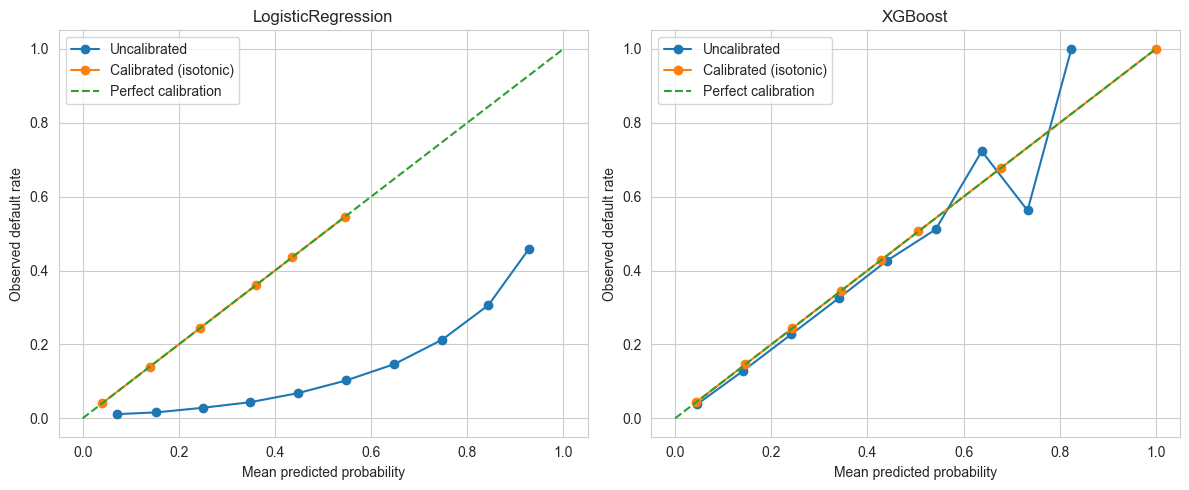

In [28]:
# Reliability Diagrams — Tuned Candidates

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

for ax, model_name in zip(
    axes,
    tuned_candidates.keys()
):

    raw_oof_proba = tuned_oof_predictions[model_name]
    selected_method = calibrators[model_name]["selected_method"]

    calibrated_oof_proba = calibrated_oof_predictions[
        f"{model_name}__{selected_method}"
    ]

    frac_raw, mean_raw = calibration_curve(
        y_train,
        raw_oof_proba,
        n_bins=10
    )

    frac_cal, mean_cal = calibration_curve(
        y_train,
        calibrated_oof_proba,
        n_bins=10
    )

    ax.plot(
        mean_raw,
        frac_raw,
        marker="o",
        label="Uncalibrated"
    )

    ax.plot(
        mean_cal,
        frac_cal,
        marker="o",
        label=f"Calibrated ({selected_method})"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed default rate")
    ax.set_title(model_name)
    ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "calibration_reliability_diagrams.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 8. Final evaluation on the locked Test set — the ONLY time Test is used

Applied exactly once: the final calibrated model transforms and scores `X_test`, and the threshold
chosen in Section 6 (from Train/OOF data only) is applied to get hard predictions.

LogisticRegression | Calibration: isotonic | Final threshold: 0.090 | OOF cost: 125437
XGBoost | Calibration: isotonic | Final threshold: 0.090 | OOF cost: 126803

FINAL TEST-SET RESULTS :
             model calibration  threshold  roc_auc  pr_auc  recall  precision     f1  brier_score    TN    FP   FN   TP  business_cost
LogisticRegression    isotonic       0.09   0.7747  0.2569  0.6731     0.1816 0.2860       0.0668 41475 15063 1623 3342          31293
           XGBoost    isotonic       0.09   0.7715  0.2544  0.6634     0.1840 0.2882       0.0669 41934 14604 1671 3294          31314


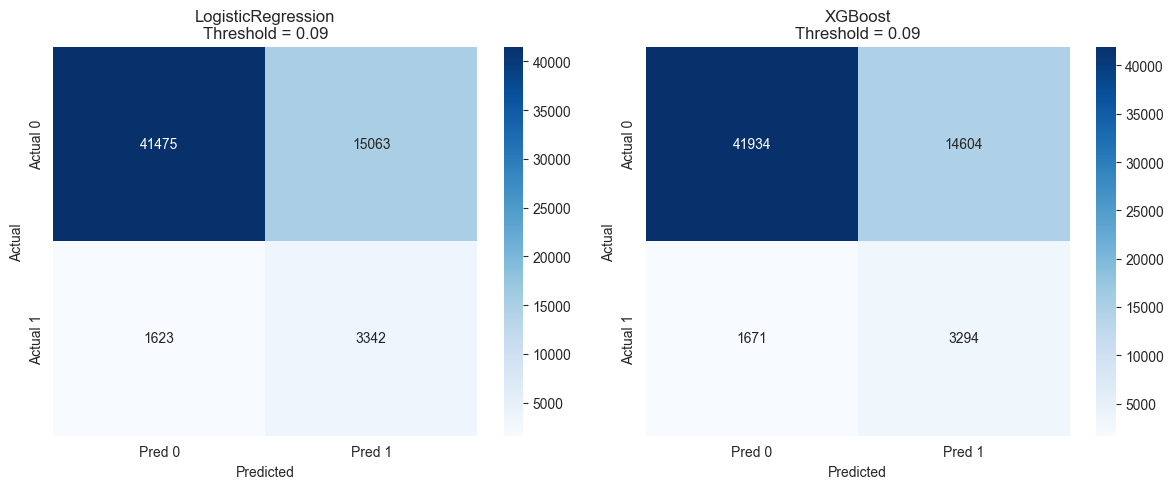

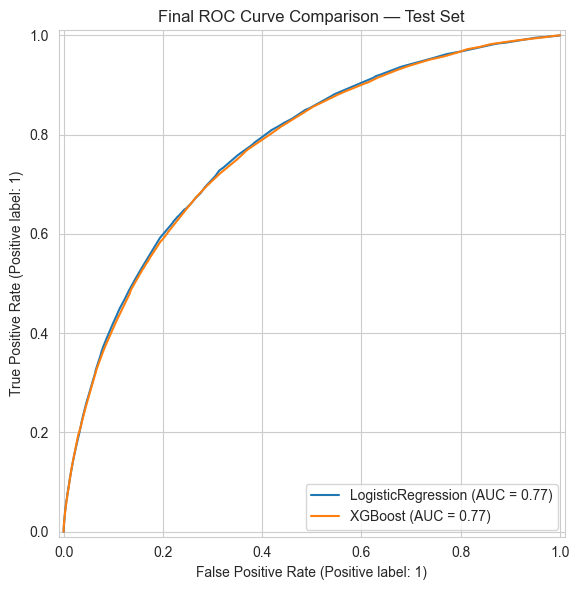


Test default rate: 8.07%
Train default rate: 8.07%

[OK] Final test evaluation completed.


In [30]:
# Final Test Evaluation — Tuned + Calibrated Candidates


FN_COST = 10
FP_COST = 1

# 1. Final candidates

final_candidates = {
    "LogisticRegression": {
        "pipeline": tuned_logistic_pipeline,
        "calibration_method": calibrators["LogisticRegression"]["selected_method"],
    },
    "XGBoost": {
        "pipeline": tuned_xgb_pipeline,
        "calibration_method": calibrators["XGBoost"]["selected_method"],
    },
}


# 2. Re-optimize threshold AFTER calibration
#    Still using Training OOF predictions only

final_thresholds = {}
final_oof_proba = {}

for model_name, info in final_candidates.items():

    method = info["calibration_method"]

    calibrated_oof_proba = calibrated_oof_predictions[
        f"{model_name}__{method}"
    ]

    final_oof_proba[model_name] = calibrated_oof_proba

    best_cost = np.inf
    best_threshold = None

    for threshold in thresholds:

        pred = (
            calibrated_oof_proba >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            pred
        ).ravel()

        total_cost = (
            fn * FN_COST +
            fp * FP_COST
        )

        if total_cost < best_cost:
            best_cost = total_cost
            best_threshold = threshold

    final_thresholds[model_name] = best_threshold

    print(
        f"{model_name} | "
        f"Calibration: {method} | "
        f"Final threshold: {best_threshold:.3f} | "
        f"OOF cost: {best_cost:.0f}"
    )


# 3. FINAL TEST EVALUATION
#    Test is used ONLY here

final_test_results = []
test_predictions = {}


for model_name, info in final_candidates.items():

    pipeline = info["pipeline"]
    method = info["calibration_method"]

    # Raw probability from tuned model
    raw_test_proba = pipeline.predict_proba(
        X_test
    )[:, 1]

    # Apply the already-fitted calibration mapping
    calibrator = calibrators[model_name][method]

    if method == "isotonic":
        test_proba = calibrator.predict(
            raw_test_proba
        )

    elif method == "sigmoid":
        test_proba = calibrator.predict_proba(
            raw_test_proba.reshape(-1, 1)
        )[:, 1]

    else:
        raise ValueError(
            f"Unknown calibration method: {method}"
        )

    threshold = final_thresholds[model_name]

    test_pred = (
        test_proba >= threshold
    ).astype(int)

    test_predictions[model_name] = test_pred

    # Metrics
    roc_auc = roc_auc_score(
        y_test,
        test_proba
    )

    pr_auc = average_precision_score(
        y_test,
        test_proba
    )

    recall = recall_score(
        y_test,
        test_pred
    )

    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_pred
    )

    brier = brier_score_loss(
        y_test,
        test_proba
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred
    ).ravel()

    test_cost = (
        fn * FN_COST +
        fp * FP_COST
    )

    final_test_results.append({
        "model": model_name,
        "calibration": method,
        "threshold": threshold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "brier_score": brier,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "business_cost": test_cost,
    })


# 4. Final comparison table

final_test_df = (
    pd.DataFrame(final_test_results)
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nFINAL TEST-SET RESULTS :")

print(
    final_test_df.round(4).to_string(
        index=False
    )
)


# 5. Save final test metrics

final_test_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "final_test_model_comparison.csv"
    ),
    index=False
)


with open(
    os.path.join(
        REPORTS_DIR,
        "final_thresholds_after_calibration.json"
    ),
    "w"
) as f:

    json.dump(
        {
            "FN_COST": FN_COST,
            "FP_COST": FP_COST,
            "thresholds": {
                model: float(threshold)
                for model, threshold
                in final_thresholds.items()
            },
            "calibration_methods": {
                model: info["calibration_method"]
                for model, info
                in final_candidates.items()
            },
        },
        f,
        indent=2
    )


# 6. Confusion matrices — Test

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, model_name in zip(
    axes,
    final_candidates.keys()
):

    cm = confusion_matrix(
        y_test,
        test_predictions[model_name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    ax.set_title(
        f"{model_name}\n"
        f"Threshold = {final_thresholds[model_name]:.2f}"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "final_test_confusion_matrices.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# 7. ROC curves — Test

fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model_name, info in final_candidates.items():

    test_proba = (
        info["pipeline"]
        .predict_proba(X_test)[:, 1]
    )

    calibrator = calibrators[
        model_name
    ][
        info["calibration_method"]
    ]

    if info["calibration_method"] == "isotonic":
        test_proba = calibrator.predict(
            test_proba
        )

    else:
        test_proba = calibrator.predict_proba(
            test_proba.reshape(-1, 1)
        )[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        test_proba,
        name=model_name,
        ax=ax
    )


ax.set_title(
    "Final ROC Curve Comparison — Test Set"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "final_test_roc_comparison.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# 8. Test-set default rate

print(
    f"\nTest default rate: {y_test.mean():.2%}"
)

print(
    f"Train default rate: {y_train.mean():.2%}"
)

print(
    "\n[OK] Final test evaluation completed."
)

## 9. Feature importance & risk-segment error analysis

Feature importance comes from the underlying tuned model when it exposes one natively
(`feature_importances_` for tree ensembles, `coef_` for Logistic Regression). Risk-segment error
analysis buckets Test applicants by predicted probability and reports the actual default rate and
error pattern per bucket - useful for spotting whether errors concentrate in a particular risk band.

Top 20 features — LogisticRegression
                                     feature  importance
                        num__AMT_GOODS_PRICE    0.742210
                             num__AMT_CREDIT    0.707696
         num__PREV_INST_AMT_PAYMENT_MIN_MEAN    0.582967
    cat__ORGANIZATION_TYPE_Transport: type 3    0.411267
                           num__EXT_SOURCE_3    0.391125
             cat__ORGANIZATION_TYPE_Military    0.374703
                           num__EXT_SOURCE_2    0.374504
      num__PREV_INST_AMT_INSTALMENT_STD_MEAN    0.361162
         cat__ORGANIZATION_TYPE_Construction    0.282472
      num__PREV_INST_AMT_INSTALMENT_MIN_MEAN    0.276129
              cat__ORGANIZATION_TYPE_Realtor    0.276049
               cat__ORGANIZATION_TYPE_Police    0.269256
        cat__ORGANIZATION_TYPE_Trade: type 2    0.249208
num__PREV_POS_CNT_INSTALMENT_FUTURE_MEAN_MAX    0.248748
         num__BUREAU_AMT_CREDIT_SUM_DEBT_SUM    0.247123
     cat__OCCUPATION_TYPE_Low-skill Laborers    0.2

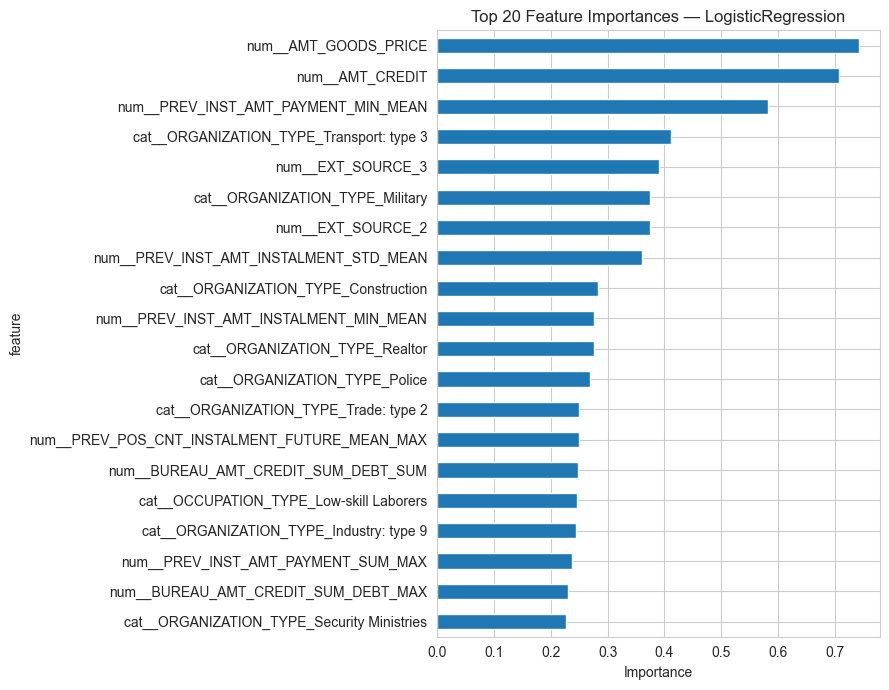

Top 20 features — XGBoost
                                               feature  importance
                                   cat__FLAG_OWN_CAR_Y    0.128119
                      cat__EMERGENCYSTATE_MODE_missing    0.044681
cat__NAME_EDUCATION_TYPE_Secondary / secondary special    0.040527
                cat__WEEKDAY_APPR_PROCESS_START_MONDAY    0.039089
              cat__WEEKDAY_APPR_PROCESS_START_THURSDAY    0.033475
                                   cat__FLAG_OWN_CAR_N    0.032341
               cat__WEEKDAY_APPR_PROCESS_START_TUESDAY    0.031293
                                  num__FLAG_DOCUMENT_3    0.031096
                       cat__NAME_FAMILY_STATUS_Married    0.030088
                cat__WEEKDAY_APPR_PROCESS_START_FRIDAY    0.029328
                         cat__OCCUPATION_TYPE_Laborers    0.027652
                                cat__FLAG_OWN_REALTY_N    0.023177
                                       num__FLAG_PHONE    0.019663
                           cat__EMER

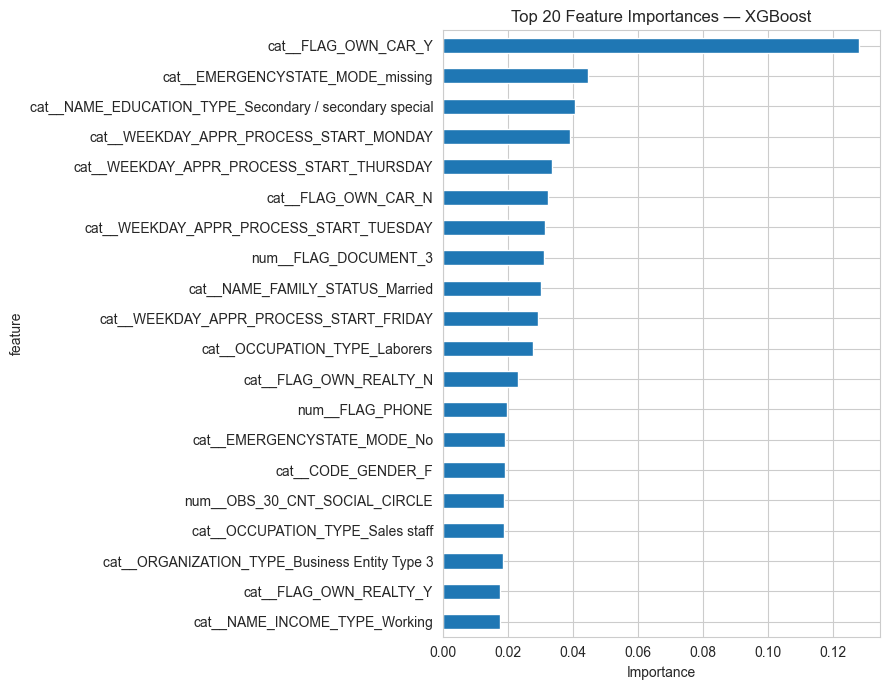

In [32]:
# Feature Importance — Tuned Logistic Regression & XGBoost


importance_results = {}

tuned_candidates = {
    "LogisticRegression": tuned_logistic_pipeline,
    "XGBoost": tuned_xgb_pipeline,
}

for model_name, pipeline in tuned_candidates.items():

    fitted_preprocessor = pipeline.named_steps["preprocessing"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    underlying_model = pipeline.named_steps["model"]

    if hasattr(underlying_model, "feature_importances_"):
        importances = underlying_model.feature_importances_

    elif hasattr(underlying_model, "coef_"):
        importances = np.abs(
            underlying_model.coef_
        ).ravel()

    else:
        print(f"[skip] No native feature importance for {model_name}")
        continue

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_results[model_name] = importance_df


    print(f"Top 20 features — {model_name}")


    print(
        importance_df
        .head(20)
        .to_string(index=False)
    )

    # Save full importance table
    importance_df.to_csv(
        os.path.join(
            REPORTS_DIR,
            f"feature_importance_{model_name}.csv"
        ),
        index=False
    )

    # Plot
    top20 = importance_df.head(20).iloc[::-1]

    fig, ax = plt.subplots(figsize=(9, 7))

    top20.plot(
        kind="barh",
        x="feature",
        y="importance",
        ax=ax,
        legend=False
    )

    ax.set_title(
        f"Top 20 Feature Importances — {model_name}"
    )

    ax.set_xlabel("Importance")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            f"feature_importance_{model_name}.png"
        ),
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

Risk-segment analysis — LogisticRegression
                  n_applicants  actual_default_rate  mean_predicted_probability  false_negatives  false_positives
risk_segment                                                                                                     
1 (lowest risk)          13082               0.0143                      0.0149              187                0
2                        12599               0.0302                      0.0309              380                0
3                        12217               0.0516                      0.0523              631                0
4                        12004               0.0933                      0.0951              425             6109
5 (highest risk)         11601               0.2282                      0.2227                0             8954


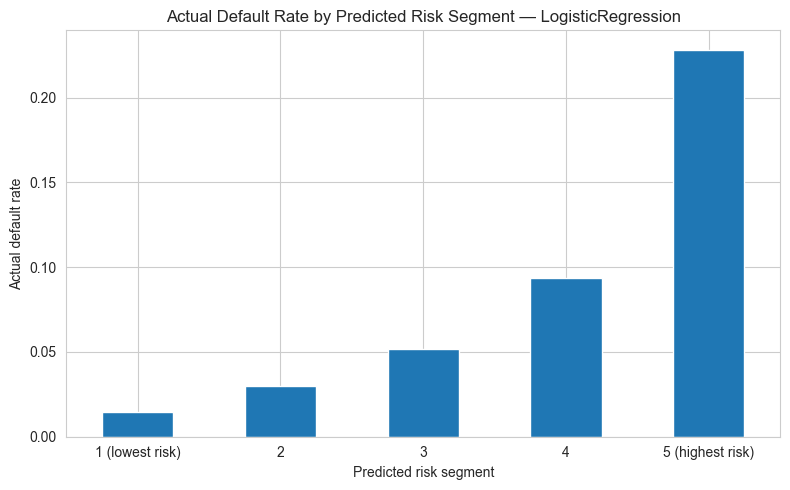

Risk-segment analysis — XGBoost
                  n_applicants  actual_default_rate  mean_predicted_probability  false_negatives  false_positives
risk_segment                                                                                                     
1 (lowest risk)          13410               0.0157                      0.0151              210                0
2                        11658               0.0302                      0.0314              352                0
3                        12950               0.0524                      0.0549              679                0
4                        11446               0.0916                      0.0936              430             5241
5 (highest risk)         12039               0.2223                      0.2175                0             9363


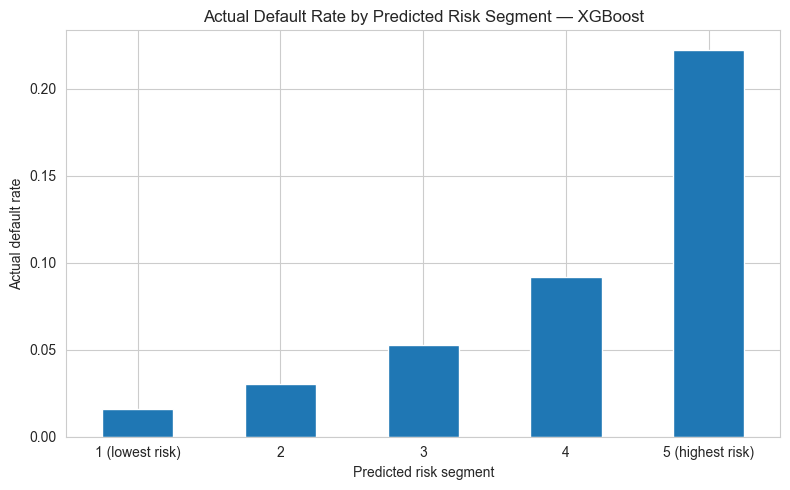

In [34]:
# Risk-Segment Error Analysis — Both Final Candidates


risk_segment_results = {}

for model_name, info in final_candidates.items():

    pipeline = info["pipeline"]
    method = info["calibration_method"]
    threshold = final_thresholds[model_name]

    # Raw test probabilities from tuned model
    raw_test_proba = pipeline.predict_proba(
        X_test
    )[:, 1]

    # Apply selected calibration
    calibrator = calibrators[model_name][method]

    if method == "isotonic":
        test_proba = calibrator.predict(
            raw_test_proba
        )

    elif method == "sigmoid":
        test_proba = calibrator.predict_proba(
            raw_test_proba.reshape(-1, 1)
        )[:, 1]

    else:
        raise ValueError(
            f"Unknown calibration method: {method}"
        )

    test_pred = (
        test_proba >= threshold
    ).astype(int)

    segment_df = pd.DataFrame({
        "y_true": y_test.values,
        "y_proba": test_proba,
        "y_pred": test_pred
    })

    # Five equal-sized probability groups
    segment_df["risk_segment"] = pd.qcut(
        segment_df["y_proba"],
        q=5,
        labels=[
            "1 (lowest risk)",
            "2",
            "3",
            "4",
            "5 (highest risk)"
        ],
        duplicates="drop"
    )

    segment_summary = (
        segment_df
        .groupby("risk_segment", observed=True)
        .agg(
            n_applicants=("y_true", "size"),
            actual_default_rate=("y_true", "mean"),
            mean_predicted_probability=("y_proba", "mean"),
            false_negatives=(
                "y_true",
                lambda s: (
                    (s == 1)
                    &
                    (
                        segment_df.loc[
                            s.index,
                            "y_pred"
                        ] == 0
                    )
                ).sum()
            ),
            false_positives=(
                "y_true",
                lambda s: (
                    (s == 0)
                    &
                    (
                        segment_df.loc[
                            s.index,
                            "y_pred"
                        ] == 1
                    )
                ).sum()
            )
        )
    )

    risk_segment_results[model_name] = segment_summary

    print(f"Risk-segment analysis — {model_name}")

    print(
        segment_summary
        .round(4)
        .to_string()
    )

    segment_summary.to_csv(
        os.path.join(
            REPORTS_DIR,
            f"risk_segment_error_analysis_{model_name}.csv"
        )
    )

    # Plot actual default rate by risk segment
    fig, ax = plt.subplots(figsize=(8, 5))

    segment_summary["actual_default_rate"].plot(
        kind="bar",
        ax=ax
    )

    ax.set_xlabel("Predicted risk segment")
    ax.set_ylabel("Actual default rate")
    ax.set_title(
        f"Actual Default Rate by Predicted Risk Segment — {model_name}"
    )

    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            f"risk_segment_default_rate_{model_name}.png"
        ),
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
# XGBoost + scale_pos_weight

model_name = "XGBoost"
strategy = "class_weight"

model = get_model(model_name, strategy)
pipe = make_pipeline(model, use_smote=False)

oof_proba = cross_val_predict(
    pipe,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_predictions[f"{model_name}__{strategy}"] = oof_proba

oof_pred_label = (oof_proba >= 0.5).astype(int)

comparison_rows.append({
    "model": model_name,
    "imbalance_strategy": strategy,
    "roc_auc": roc_auc_score(y_train, oof_proba),
    "pr_auc": average_precision_score(y_train, oof_proba),
    "recall@0.5": recall_score(y_train, oof_pred_label),
    "precision@0.5": precision_score(
        y_train, oof_pred_label, zero_division=0
    ),
    "f1@0.5": f1_score(y_train, oof_pred_label),
})

print(f"[done] {model_name} + {strategy}")

[done] XGBoost + class_weight


## 10. Save the Final Classical Model and Supporting Artifacts

Logistic Regression is selected as the final classical champion, while XGBoost is retained as the challenger.

Both finalized models and their calibration/threshold settings are saved for reproducibility.

The Logistic champion is saved as `best_classical_model.joblib` and will be reused in the Deep Learning notebook without retraining.

**Classical ML stage completed.**

In [36]:
# Final Classical Model Artifacts
# Save both finalists + identify the final champion

# 1. Define the two finalized candidates

final_candidates = {
    "LogisticRegression": {
        "pipeline": tuned_logistic_pipeline,
        "calibrator": calibrators["LogisticRegression"][
            selected_calibration["LogisticRegression"]
        ],
        "calibration_method": selected_calibration[
            "LogisticRegression"
        ],
        "threshold": final_thresholds["LogisticRegression"],
        "imbalance_strategy": "class_weight",
    },

    "XGBoost": {
        "pipeline": tuned_xgb_pipeline,
        "calibrator": calibrators["XGBoost"][
            selected_calibration["XGBoost"]
        ],
        "calibration_method": selected_calibration[
            "XGBoost"
        ],
        "threshold": final_thresholds["XGBoost"],
        "imbalance_strategy": "smote",
    },
}


# 2. Final champion
#    Based on final Test PR-AUC

final_test_df = final_test_df.sort_values(
    "pr_auc",
    ascending=False
).reset_index(drop=True)

champion_name = final_test_df.iloc[0]["model"]


print("FINAL CLASSICAL MODEL SELECTION :")


print(f"Champion model: {champion_name}")
print()

print(
    final_test_df[
        [
            "model",
            "calibration",
            "threshold",
            "pr_auc",
            "roc_auc",
            "recall",
            "precision",
            "f1",
            "brier_score",
            "business_cost",
        ]
    ].round(4).to_string(index=False)
)


# 3. Save both finalized candidates

saved_candidates = {}

for model_name, info in final_candidates.items():

    # Complete reusable artifact:
    # base model + calibration + decision threshold
    artifact = {
        "model_name": model_name,
        "pipeline": info["pipeline"],
        "calibrator": info["calibrator"],
        "calibration_method": info["calibration_method"],
        "decision_threshold": float(info["threshold"]),
        "imbalance_strategy": info["imbalance_strategy"],
    }

    filename = (
        "logistic_regression_final.joblib"
        if model_name == "LogisticRegression"
        else "xgboost_final.joblib"
    )

    artifact_path = os.path.join(
        MODELS_DIR,
        filename
    )

    joblib.dump(
        artifact,
        artifact_path
    )

    saved_candidates[model_name] = artifact_path

    print(f"[saved] {model_name}: {artifact_path}")


# 4. Save the champion separately
#    This is the artifact the DL notebook can load directly.

champion_artifact = joblib.load(
    saved_candidates[champion_name]
)

champion_path = os.path.join(
    MODELS_DIR,
    "best_classical_model.joblib"
)

joblib.dump(
    champion_artifact,
    champion_path
)

print()
print(f"[saved] Final champion: {champion_path}")


# 5. Build final metadata

final_model_metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),

    "champion_model": champion_name,

    "selection_metric": "PR-AUC",

    "candidates": {}
}

for model_name, info in final_candidates.items():

    row = final_test_df[
        final_test_df["model"] == model_name
    ].iloc[0]

    pipeline = info["pipeline"]
    underlying_model = pipeline.named_steps["model"]

    # Get tuned hyperparameters from the underlying model
    model_params = underlying_model.get_params()

    selected_params = {}

    if model_name == "LogisticRegression":
        selected_params = {
            "C": float(model_params["C"]),
            "solver": model_params["solver"],
            "max_iter": model_params["max_iter"],
        }

    elif model_name == "XGBoost":
        selected_params = {
            "n_estimators": int(
                model_params["n_estimators"]
            ),
            "max_depth": int(
                model_params["max_depth"]
            ),
            "learning_rate": float(
                model_params["learning_rate"]
            ),
            "subsample": float(
                model_params["subsample"]
            ),
        }

    final_model_metadata["candidates"][model_name] = {
        "imbalance_strategy": info["imbalance_strategy"],
        "calibration_method": info["calibration_method"],
        "decision_threshold": float(
            info["threshold"]
        ),
        "best_hyperparameters": selected_params,

        "final_test_metrics": {
            "roc_auc": float(row["roc_auc"]),
            "pr_auc": float(row["pr_auc"]),
            "recall": float(row["recall"]),
            "precision": float(row["precision"]),
            "f1": float(row["f1"]),
            "brier_score": float(row["brier_score"]),
            "business_cost": float(row["business_cost"]),
        },

        "confusion_matrix": {
            "TN": int(row["TN"]),
            "FP": int(row["FP"]),
            "FN": int(row["FN"]),
            "TP": int(row["TP"]),
        },

        "feature_count_before_encoding": len(
            feature_lists["all_features"]
        ),

        "transformed_feature_count": len(
            final_candidates[model_name]["pipeline"]
            .named_steps["preprocessing"]
            .get_feature_names_out()
        ),

        "random_state": RANDOM_STATE,

        "artifact_path": saved_candidates[model_name],
    }


# 6. Save metadata

metadata_path = os.path.join(
    REPORTS_DIR,
    "final_model_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(
        final_model_metadata,
        f,
        indent=2
    )


# 7. Save final comparison

final_test_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        "final_test_model_comparison.csv"
    ),
    index=False
)


print("\nFINAL CLASSICAL ML ARTIFACTS SAVED :")


print(f"Champion: {champion_name}")
print(f"Champion artifact: {champion_path}")
print(f"Metadata: {metadata_path}")

print("\nSaved candidate models:")
for model_name, path in saved_candidates.items():
    print(f" - {model_name}: {path}")

print("\n[OK] Classical ML stage completed.")
print("[OK] The champion model is saved and will NOT be retrained in the DL notebook.")

FINAL CLASSICAL MODEL SELECTION :
Champion model: LogisticRegression

             model calibration  threshold  pr_auc  roc_auc  recall  precision     f1  brier_score  business_cost
LogisticRegression    isotonic       0.09  0.2569   0.7747  0.6731     0.1816 0.2860       0.0668          31293
           XGBoost    isotonic       0.09  0.2544   0.7715  0.6634     0.1840 0.2882       0.0669          31314
[saved] LogisticRegression: C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\models\versioned_artifacts\logistic_regression_final.joblib
[saved] XGBoost: C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project structure Project\project-name\models\versioned_artifacts\xgboost_final.joblib

[saved] Final champion: C:\Users\Kirolos George\OneDrive - Alexandria University\Desktop\projects\tech_trek_internship\credit risk project struct

In [37]:
# Section 11 — Final Classical ML Summary

champion_row = final_test_df[
    final_test_df["model"] == champion_name
].iloc[0]


print("FINAL CLASSICAL ML SUMMARY :")


print(f"Champion model:       {champion_name}")
print(f"Imbalance strategy:   {final_candidates[champion_name]['imbalance_strategy']}")
print(f"Calibration method:   {final_candidates[champion_name]['calibration_method']}")
print(f"Decision threshold:   {final_candidates[champion_name]['threshold']:.3f}")

print("\nTest-set metrics:")
for metric in [
    "pr_auc",
    "roc_auc",
    "recall",
    "precision",
    "f1",
    "brier_score",
    "business_cost",
]:
    print(f"  {metric:<15}: {champion_row[metric]:.4f}")

print("\nConfusion matrix (Test):")
print(
    pd.DataFrame(
        [[
            champion_row["TN"],
            champion_row["FP"]
        ], [
            champion_row["FN"],
            champion_row["TP"]
        ]],
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
)

print("\nChallenger: XGBoost")
xgb_row = final_test_df[
    final_test_df["model"] == "XGBoost"
].iloc[0]

print(f"  PR-AUC:  {xgb_row['pr_auc']:.4f}")
print(f"  ROC-AUC: {xgb_row['roc_auc']:.4f}")
print(f"  F1:      {xgb_row['f1']:.4f}")


print("\n[STOP HERE] Classical ML track complete.")
print("The champion model is saved and will be reused in the Deep Learning notebook.")


FINAL CLASSICAL ML SUMMARY :
Champion model:       LogisticRegression
Imbalance strategy:   class_weight
Calibration method:   isotonic
Decision threshold:   0.090

Test-set metrics:
  pr_auc         : 0.2569
  roc_auc        : 0.7747
  recall         : 0.6731
  precision      : 0.1816
  f1             : 0.2860
  brier_score    : 0.0668
  business_cost  : 31293.0000

Confusion matrix (Test):
          Pred 0  Pred 1
Actual 0   41475   15063
Actual 1    1623    3342

Challenger: XGBoost
  PR-AUC:  0.2544
  ROC-AUC: 0.7715
  F1:      0.2882

[STOP HERE] Classical ML track complete.
The champion model is saved and will be reused in the Deep Learning notebook.


## Current Project Structure

```text
project-name/
│
├── data/
│   ├── raw/
│   │   └── Home Credit raw CSV files
│   │
│   └── processed/
│       ├── final_feature_dataset.csv
│       ├── X_train.csv
│       ├── X_test.csv
│       ├── y_train.csv
│       └── y_test.csv
│
├── notebooks/
│   ├── 01_eda.ipynb
│   ├── 02_feature_engineering.ipynb
│   ├── 03_ml_experiments.ipynb
│   
│   
│
├── src/
│   └── data/
│       └── collected_dataset.csv
│
├── app/
│   
│
├── models/
│   └── versioned_artifacts/
│       ├── preprocessing_pipeline.joblib
│       ├── logistic_regression_final.joblib
│       ├── xgboost_final.joblib
│       └── best_classical_model.joblib
│
├── reports/
│   ├── figures/
│   │   └── EDA + ML figures
│   │
│   ├── eda_decision_log.csv
│   ├── final_ml_feature_list.json
│   ├── validation_strategy.json
│   ├── model_comparison_cv_results.csv
│   ├── tuned_model_comparison.csv
│   ├── threshold_analysis.csv
│   ├── optimal_thresholds.json
│   ├── calibration_comparison.csv
│   ├── selected_calibration_methods.json
│   ├── final_thresholds_after_calibration.json
│   ├── final_test_model_comparison.csv
│   ├── feature_importance_*.csv
│   ├── risk_segment_error_analysis_*.csv
│   └── final_model_metadata.json
│
└──  requirements.txt